# Plotting Overview

SpectroChemPy plotting is designed to be:

- **Automatic** – sensible defaults are chosen for you.
- **Consistent** – similar data produces similar visuals.
- **Customizable** – override anything locally or globally.
- **Style-driven** – visual appearance can be changed without rewriting code.

In most cases, plotting your data requires only one line.

## Your First Plot

Once a dataset is loaded, simply call the `plot()` method:

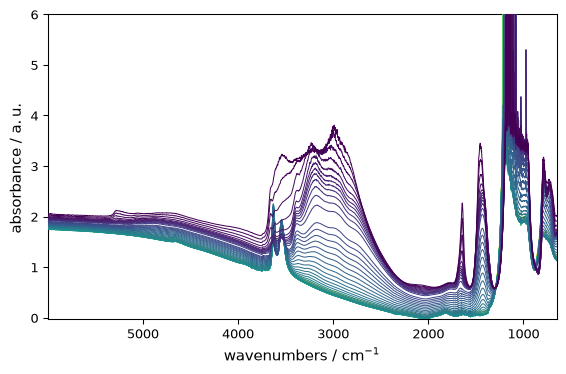

In [1]:
import spectrochempy as scp

ds = scp.read("irdata/nh4y-activation.spg")
_ = ds.plot()

That’s it.

Here SpectroChemPy automatically:

- Detects the dataset is 2D and chooses an appropriate plot type (stacked lines in this case).
- Selects a suitable colormap (sequential because the y-dimension is a time axis)
- Adds axis labels from dataset metadata.
- Adjusts layout and scaling.

In most situations, no additional configuration is needed.

## Automatic Plot Type Selection

The `plot()` method adapts to the dimensionality of your dataset:

| Dataset type | Default plot |
|--------------|--------------|
| 1D / 2D      | Line(s) plot |
| 2D field     | Image / contour (depending on method) |

But you can also explicitly choose another plotting method:

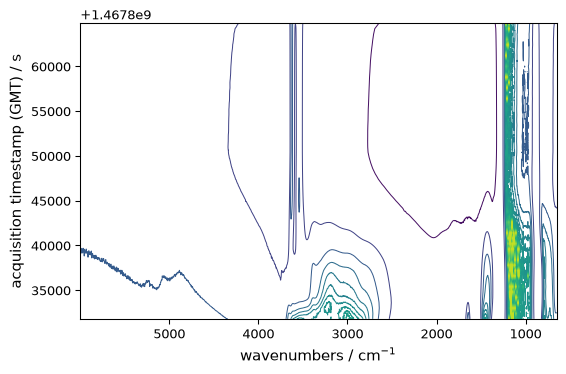

In [2]:
_ = ds.plot_contour()

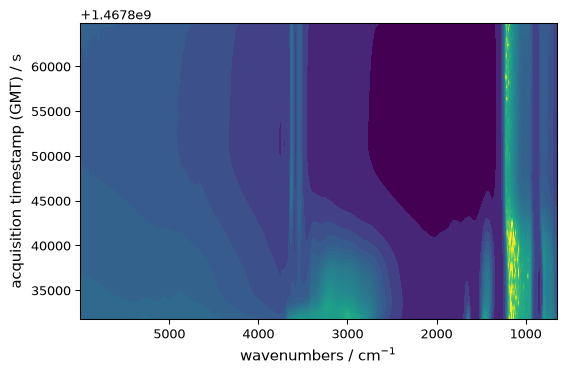

In [3]:
_ = ds.plot_image()

## Automatic Color Selection

SpectroChemPy chooses colors intelligently:

- for lines:
  - Sequential data → sequential palette lines (default viridis, defined by `prefs.colormap_sequential`)
  - Categorical stacks → distinct categorical colors (default tab10 or tab20 depending on number of lines)
- for contours and images:
  - Data with both positive and negative values → diverging colormap (default RdBu_r, defined by `prefs.colormap_diverging`)
  - Data with only positive or only negative values → sequential colormap (default viridis, defined by
  `prefs.colormap_sequential`)

This behavior works automatically — no configuration required.

For line plots, however, you can disable continuous colormaps and force use categorical colors:

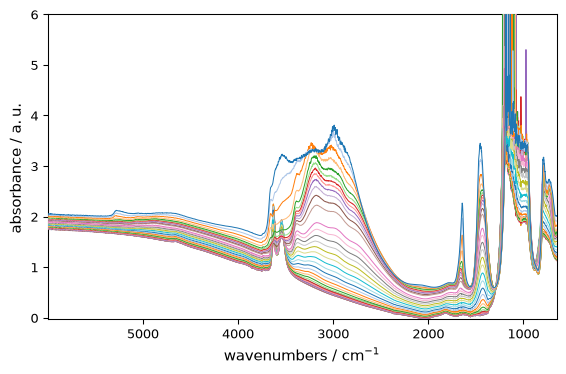

In [4]:
_ = ds.plot_lines(palette="categorical")

For images and contours, you can also override the default sequential/diverging colormap behavior. Lets first have a
a dataset with both positive and negative values:
ds_neg = ds - ds.mean()
ds_neg.plot_image(colorbar=True)

As expected,the default diverging colormap has been chosen . But this can be overriden using:

ds_neg.plot_image(cmap_mode='sequential')   # forces sequential colormap even for data with negative values

The switch between sequential and diverging colormaps is based on the actual data values, with a `diverging_margin`
which fixes the minimum ratio threshold for diverging auto-detection. If the data contains negative values, but they
are small compared to the overall data range (i.e. they are less than `diverging_margin` of the data range), then a
sequential colormap will be used instead of a diverging one. This prevents the use of diverging colormaps when the
negative (resp. positive) values are negligible compared to the positive (resp. negative) values, which would not
provide meaningful color differentiation. The default value for `diverging_margin` is 0.05, meaning that if the
negative values are less than 5% of the data range, a sequential colormap will be used even if there are negative
values present.
You can adjust this threshold as needed. For example, in the above example, setting `diverging_margin=0.5` will
allows for a much larger proportion of negative values (up to 50% of the data range) before switching to a diverging
colormap, which is why the sequential colormap is used in this case:
ds_neg.plot_image(diverging_margin=0.5)

## Colorbars

By default SpectroChemPy never print a colorbar.  But using the option `colorbar=auto` will make it print  whenever
a sequential or diverging colormap is used/

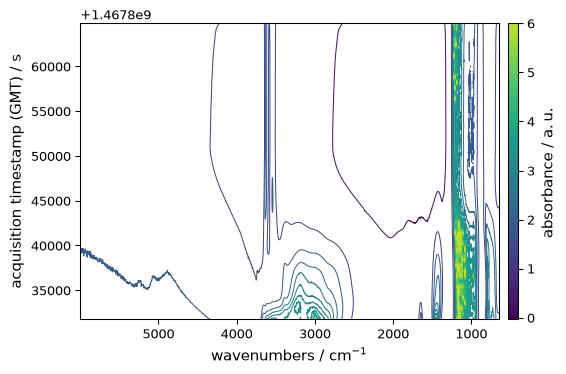

In [5]:
_ = ds.plot_contour(colorbar="auto")  # shows colorbar whenever applicable

## Changing the Colormap

You can change colors per plot:

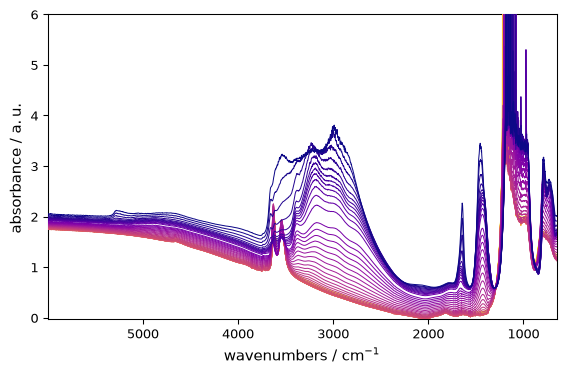

In [6]:
_ = ds.plot(cmap="plasma")  # note that palette="plasma" would also work for line plots

## Colormap Precedence

When choosing a colormap, SpectroChemPy follows this priority order:

1. **Explicit `cmap` kwarg** (i.e. `cmap=XXX` passed in plot() — highest priority
2. **Preferences colormap** — if set and not "auto" (see preferences documentation)
3. **Matplotlib style** — if the style sets `image.cmap` and prefs.colormap is "auto" (see styles documentation)
4. **Default preferences** — `prefs.colormap_sequential` or `prefs.colormap_diverging` (see preferences documentation)

This means:
- `ds.plot(cmap="inferno")` always uses inferno
- `prefs.colormap = "cividis"` uses cividis (unless overridden by explicit cmap)
- `ds.plot(style="grayscale")` with `prefs.colormap="auto"` uses grayscale
- Default behavior uses preferences-defined sequential/diverging colormaps

## Changing the Overall Style

You can change the visual appearance using styles:

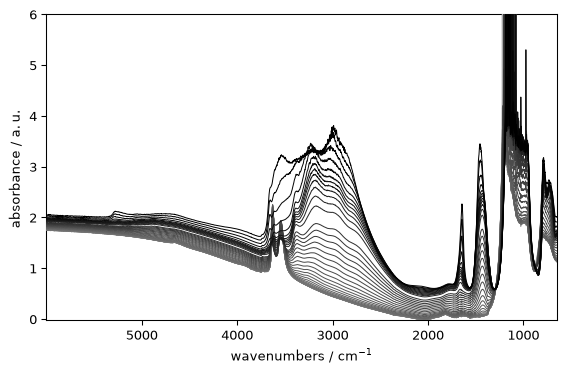

In [7]:
_ = ds.plot(style="grayscale")

Styles can affect fonts, grid appearance, backgrounds, and (in auto mode) colormap defaults. When passes in a
`plot()` function the change is on a ped-plot basis. You can also set a style globally and persistently using
`scp.preferences.style`, which will affect all subsequent plots.

## The Mental Model

In practice:

- `ds.plot()` just works.
- `cmap=` (or `palette=` for lines) changes colors.
- `colorbar=` controls the colorbar.
- `style=` changes the overall appearance.
- `scp.preferences` changes defaults persistently.

Everything else is optional.

In the following sections, we will explore how to customize plots in more detail.